## Implementation Details: DRD2 Active Max-Finding Benchmark

This notebook runs an **active-learning benchmark for molecular max-finding** on the TDC DRD2 oracle, comparing:

- `high_prior_dpp`: optimistic mean-only acquisition + greedy k-DPP batch diversification
- `random`: uniform random batch acquisition
- `ucb_mc_dropout`: Monte Carlo dropout UCB baseline

The goal is **query efficiency**: find high-scoring molecules with as few oracle calls as possible.

### 1) Problem Setup

Given a fixed candidate pool $\mathcal{P} = \{x_i\}_{i=1}^N$ of molecules (SMILES), each has an oracle score
$$
y(x) \in [0,1], \quad y(x) = \text{DRD2Oracle}(x).
$$

At each active-learning round $t$, we maintain a queried set $\mathcal{D}_t$ and an unlabeled set $\mathcal{U}_t = \mathcal{P} \setminus \mathcal{D}_t$.

We optimize max-finding metrics:

- **Best-so-far**
$$
b_t = \max_{x \in \mathcal{D}_t} y(x)
$$
- **Simple regret to observed pool max**
$$
r_t = y^*_{\text{pool}} - b_t, \quad y^*_{\text{pool}} = \max_{x \in \mathcal{P}} y(x)
$$
- **Queries-to-threshold** for $0.95\,y^*_{\text{pool}}$ and $0.98\,y^*_{\text{pool}}$.

### 2) Molecular Featurization and Graph Construction

Each molecule is converted to a graph using RDKit:

- Nodes: atoms
- Edges: undirected bonds
- Self-loops are added

Per-atom feature vector (dimension 8):

1. atomic number / 100
2. total degree / 6
3. formal charge / 5
4. aromatic indicator
5. hybridization is SP (binary)
6. hybridization is SP2 (binary)
7. hybridization is SP3 (binary)
8. total hydrogens / 8

For batching, graphs are padded to max nodes in batch. Adjacency is row-normalized:
$$
\tilde{A}_{ij} = \frac{A_{ij}}{\sum_k A_{ik}}.
$$

### 3) GNN Surrogate Architecture (No Prior Bias in Model)

The surrogate model (`HighPriorGNN`) is a plain graph regressor with sigmoid output:

- Input projection: $\mathbb{R}^{8} \to \mathbb{R}^{d_h}$
- $L$ message-passing blocks (`GraphConvLayer`), each:
$$
H' = \mathrm{ReLU}(W_s H + W_n (\tilde{A}H)), \quad H' = \mathrm{Dropout}(H')
$$
- Masked mean pooling over nodes:
$$
z = \frac{\sum_i m_i h_i}{\sum_i m_i}
$$
- Readout embedding:
$$
e = \mathrm{ReLU}(W_r z)
$$
- Output head (no fixed prior term in architecture):
$$
\hat{y}(x) = \sigma\left(w_o^\top e\right)
$$

Initialization detail:

- final output weights and bias are initialized to zero

So at initialization the model starts at zero logit (mean probability $\sigma(0)=0.5$), including for UCB.

### 4) Training Protocol

At every round and for each method, the surrogate is retrained on current queried labels only:

- Loss: MSE
$$
\mathcal{L} = \frac{1}{|\mathcal{B}|}\sum_{x \in \mathcal{B}} \left(\hat{y}(x) - y(x)\right)^2
$$
- Optimizer: Adam
- Mini-batch SGD over queried indices

### 5) Acquisition Functions

#### 5.1 High-prior mean-only acquisition (`high_prior_dpp`)

The high-prior optimism is applied **only in acquisition**, not in the network forward pass.

Let
$$
\beta_0 = \mathrm{logit}(\texttt{prior\_mean}), \quad \text{default } \texttt{prior\_mean}=0.95.
$$

Model predictive mean is transformed in logit space before ranking:
$$
a(x) = \sigma\left(\mathrm{logit}(\hat{y}(x)) + \beta_0\right).
$$

Pipeline:

1. score all unlabeled molecules with $a(x)$
2. keep top `shortlist_size`
3. from shortlist, keep top `dpp_candidates` for diversity optimization
4. select batch of size $k$ via greedy k-DPP MAP

k-DPP kernel (quality-weighted similarity):
$$
L = \mathrm{diag}(q)\,S\,\mathrm{diag}(q)
$$
with
$$
q_i = \exp\left(\frac{a_i}{\tau}\right),
\quad
S_{ij} = \exp\left(-\frac{\|e_i-e_j\|^2}{\sigma^2}\right).
$$

Implementation uses numerically stabilized qualities:
$$
q_i = \exp\left(\frac{a_i-\max_j a_j}{\tau}\right)
$$
(clipped exponent range in code), and
$$
\sigma = \mathrm{median}\left(\|e_i-e_j\|: i\neq j\right)
$$
computed on the DPP candidate pool.

Greedy MAP objective:
$$
\max_{Y:|Y|=k} \log \det\left(L_Y\right)
$$
(using `slogdet` and iterative best-addition).

#### 5.2 Random baseline (`random`)

Uniformly samples $k$ molecules from unlabeled pool each round.

#### 5.3 UCB baseline (`ucb_mc_dropout`)

UCB uses the same unbiased model (zero-logit initialization) and does **not** include $\beta_0$.

Uses MC dropout to estimate predictive moments on unlabeled points:
$$
\mu(x) = \frac{1}{T}\sum_{t=1}^T \hat{y}^{(t)}(x),
\quad
\sigma(x) = \sqrt{\frac{1}{T}\sum_{t=1}^T\left(\hat{y}^{(t)}(x)-\mu(x)\right)^2}
$$

UCB score:
$$
a_{\text{UCB}}(x)=\mu(x)+\beta\sigma(x).
$$

Top-$k$ by UCB are queried.

### 6) Reproducibility and Runtime

- Seeds are set for Python, NumPy, and PyTorch.
- Device is GPU-first (`cuda` if available) with CPU fallback.
- Round-level logs include queried count, best-so-far score, and runtime.

### 7) Delivered Outputs

This notebook computes and visualizes:

- per-method trajectories of best-so-far vs queries
- per-method simple-regret vs queries
- summary table including final performance and threshold-query metrics

The corresponding Python implementation is in `drd2_maxfinding_benchmark.py`, and this notebook is the experimental driver.

# DRD2 Active Max-Finding Benchmark (High Prior Mean + k-DPP)

This notebook executes a max-finding active-learning benchmark on TDC DRD2 with:
- High-prior-mean GNN acquisition (no variance term), diversified with greedy k-DPP
- Random batch baseline
- UCB MC-dropout baseline (same surrogate/training loop)

In [6]:
%load_ext autoreload
%autoreload 1
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%aimport drd2_maxfinding_benchmark


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
# Larger representative experiment tuned for stronger max-finding performance.
# Expected runtime target: ~15-30 minutes on RTX 3060 (depends on system load).
cfg = drd2_maxfinding_benchmark.BenchmarkConfig(
    seed=123,
    pool_size=12000,
    seed_size=96,
    rounds=32,
    batch_k=64,
    train_epochs=40,
    train_batch_size=8192,
    hidden_dim=384,
    depth=5,
    shortlist_size=12000,
    dpp_candidates=512,
    tau=0.08,
    ucb_beta=3.0,
    ucb_mc_passes=24,
    pred_batch_size=8192,
    use_amp=True,
    use_tf32=True,
    cache_graphs_on_device=True,
    auto_tune_cuda_batch_sizes=False,
    prior_mean=0.92,
    lr=1e-3,
    weight_decay=1e-4,
)

out = drd2_maxfinding_benchmark.run_benchmark(cfg)
results = out["results"]
pool_max = float(np.max(out["scores"]))
print(f"Observed pool max: {pool_max:.4f}")

Found local copy...
Loading...


Done!


device=cuda
gpu=NVIDIA GeForce RTX 3060
gpu_tuned train_batch_size=8192 pred_batch_size=8192 amp=True tf32=True


Found local copy...


[high_prior_dpp] round=1/32 queried=160 best=0.3067 time=2.2s
[high_prior_dpp] round=2/32 queried=224 best=0.3067 time=3.7s
[high_prior_dpp] round=3/32 queried=288 best=0.3067 time=2.4s
[high_prior_dpp] round=4/32 queried=352 best=0.3067 time=2.6s
[high_prior_dpp] round=5/32 queried=416 best=0.3067 time=2.7s
[high_prior_dpp] round=6/32 queried=480 best=0.3067 time=2.9s
[high_prior_dpp] round=7/32 queried=544 best=0.3067 time=3.2s
[high_prior_dpp] round=8/32 queried=608 best=0.3067 time=3.3s
[high_prior_dpp] round=9/32 queried=672 best=0.3067 time=3.5s
[high_prior_dpp] round=10/32 queried=736 best=0.3067 time=3.6s
[high_prior_dpp] round=11/32 queried=800 best=0.3549 time=3.9s
[high_prior_dpp] round=12/32 queried=864 best=0.3549 time=3.9s
[high_prior_dpp] round=13/32 queried=928 best=0.3549 time=5.8s
[high_prior_dpp] round=14/32 queried=992 best=0.3549 time=4.5s
[high_prior_dpp] round=15/32 queried=1056 best=0.3549 time=4.6s
[high_prior_dpp] round=16/32 queried=1120 best=0.3549 time=4.8s

In [8]:
rows = []
for r in results:
    rows.append({
        "method": r.method,
        "final_queries": r.queries[-1],
        "best_final": r.best_so_far[-1],
        "simple_regret_final": r.simple_regret[-1],
        "queries_to_95pct_pool_max": r.threshold_q95,
        "queries_to_98pct_pool_max": r.threshold_q98,
        "mean_batch_pairwise_similarity": r.diversity_mean_similarity,
    })
summary_df = pd.DataFrame(rows).sort_values("method").reset_index(drop=True)
summary_df

,method,final_queries,best_final,simple_regret_final,queries_to_95pct_pool_max,queries_to_98pct_pool_max,mean_batch_pairwise_similarity
0,high_prior_dpp,2144,0.581282,0.389266,NaN,NaN,0.403662
1,random,2144,0.955461,0.015087,1312.0,1312.0,NaN
2,ucb_mc_dropout,2144,0.388822,0.581727,NaN,NaN,NaN


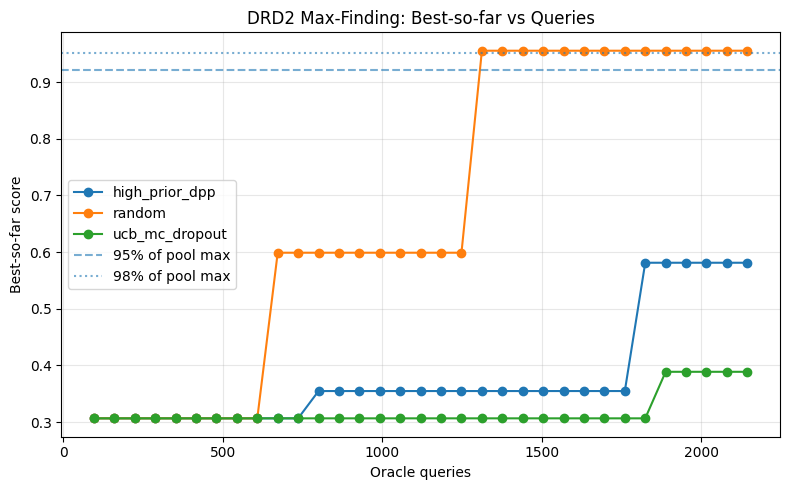

In [9]:
plt.figure(figsize=(8, 5))
for r in results:
    plt.plot(r.queries, r.best_so_far, marker="o", label=r.method)
plt.axhline(0.95 * pool_max, linestyle="--", alpha=0.6, label="95% of pool max")
plt.axhline(0.98 * pool_max, linestyle=":", alpha=0.6, label="98% of pool max")
plt.xlabel("Oracle queries")
plt.ylabel("Best-so-far score")
plt.title("DRD2 Max-Finding: Best-so-far vs Queries")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

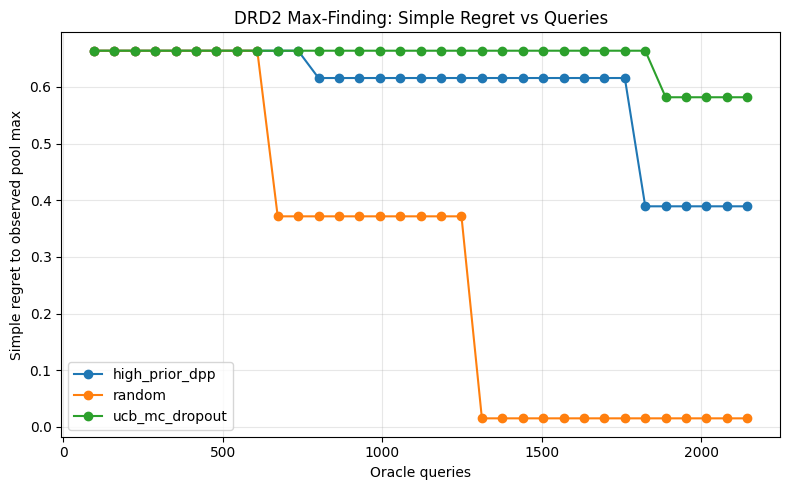

In [10]:
plt.figure(figsize=(8, 5))
for r in results:
    plt.plot(r.queries, r.simple_regret, marker="o", label=r.method)
plt.xlabel("Oracle queries")
plt.ylabel("Simple regret to observed pool max")
plt.title("DRD2 Max-Finding: Simple Regret vs Queries")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
headline = summary_df[["method", "queries_to_95pct_pool_max", "queries_to_98pct_pool_max", "best_final"]]
headline

,method,queries_to_95pct_pool_max,queries_to_98pct_pool_max,best_final
0,high_prior_dpp,NaN,NaN,0.581282
1,random,1312.0,1312.0,0.955461
2,ucb_mc_dropout,NaN,NaN,0.388822


In [12]:
from pathlib import Path

cwd = Path.cwd()
paths = {
    "data": Path("data"),
    "oracle": Path("oracle"),
    "sweep_outputs": Path("sweep_outputs"),
    "sweep_outputs_v3": Path("sweep_outputs_v3"),
}

print(f"cwd: {cwd}")
for name, p in paths.items():
    exists = p.exists()
    kind = "dir" if p.is_dir() else ("file" if p.is_file() else "missing")
    sample = []
    if p.is_dir():
        sample = sorted([x.name for x in p.iterdir()])[:5]
    print(f"{name}: exists={exists} type={kind} sample={sample}")

cwd: /home/paul/highexp-vs-ucb/drd2_benchmark
data: exists=True type=dir sample=['zinc.tab']
oracle: exists=True type=dir sample=['drd2_current.pkl']
sweep_outputs: exists=True type=dir sample=['sweep1_baseline_by_seed.json', 'sweep1_summary.csv', 'sweep1_summary.json', 'sweep1_trials.csv', 'sweep1_trials.json']
sweep_outputs_v3: exists=True type=dir sample=['acq_refine_random_by_seed.json', 'acq_refine_summary.csv', 'acq_refine_summary.json', 'acq_refine_trials.csv', 'acq_refine_trials.json']
